# 🚢 Titanic 생존자 예측: Baseline 모델링 & 실험 비교

**과제 2 — Week 3~4: Baseline 모델링 & Versioning**

---

### 실험 목표

| 목표 | 내용 |
|------|------|
| 데이터 이해 | Titanic 데이터의 구조, 결측치, 분포 파악 |
| 전처리 설계 | ColumnTransformer + Pipeline 구조 구현 |
| 모델 비교 | SVM vs KNN, 스케일링 유무에 따른 성능 차이 |
| 결과 해석 | Accuracy / F1 / Confusion Matrix 분석 |
| 재현 가능성 | Pipeline 기반 누수 없는 실험 구조 확보 |

### 실험 구성

| 실험 | 모델 | 스케일러 | 목적 |
|------|------|----------|------|
| Exp 1 | SVM | 없음 | 기준(Baseline) 확인 |
| Exp 2 | SVM | StandardScaler | 스케일링 효과 측정 |
| Exp 3 | KNN (k=5) | StandardScaler | 거리 기반 모델 비교 |
| Exp 4 | SVM | MinMaxScaler | Scaler 종류 비교 |

---

## 0. 라이브러리 로드

In [1]:
import warnings
warnings.filterwarnings('ignore')


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# 시각화 스타일
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
sns.set_palette('muted')

RANDOM_STATE = 42
print('라이브러리 로드 완료')

Matplotlib is building the font cache; this may take a moment.


라이브러리 로드 완료


---
## 1. 데이터 로드 및 기본 확인

In [2]:
df = pd.read_csv("../data/raw/titanic.csv")

print(f'데이터 크기: {df.shape[0]}행 × {df.shape[1]}열')
print(f'타겟 분포: 사망(0) = {(df.Survived==0).sum()}명 ({(df.Survived==0).mean():.1%}),  생존(1) = {(df.Survived==1).sum()}명 ({(df.Survived==1).mean():.1%})')
df.head()

데이터 크기: 891행 × 12열
타겟 분포: 사망(0) = 549명 (61.6%),  생존(1) = 342명 (38.4%)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [18]:
# 변수별 정보 요약
info_df = pd.DataFrame({
    'dtype'  : df.dtypes.astype(str),
    'missing': df.isnull().sum(),
    'missing%': (df.isnull().mean() * 100).round(1).astype(str) + '%',
    'unique' : df.nunique(),
    'sample' : [str(df[c].dropna().iloc[0]) if df[c].notna().any() else 'N/A' for c in df.columns]
})

# 결측치 있는 컬럼 강조
def highlight_missing(row):
    return ['background-color: #fff3cd' if row['missing'] > 0 else '' for _ in row]

info_df.style.apply(highlight_missing, axis=1).set_caption('⚠️ 노란색 = 결측치 존재')

,dtype,missing,missing%,unique,sample
PassengerId,int64,0,0.0%,891,1
Survived,int64,0,0.0%,2,0
Pclass,int64,0,0.0%,3,3
Name,object,0,0.0%,891,"Braund, Mr. Owen Harris"
Sex,object,0,0.0%,2,male
Age,float64,177,19.9%,88,22.0
SibSp,int64,0,0.0%,7,1
Parch,int64,0,0.0%,7,0
Ticket,object,0,0.0%,681,A/5 21171
Fare,float64,0,0.0%,248,7.25


---
## 2. 탐색적 데이터 분석 (EDA)

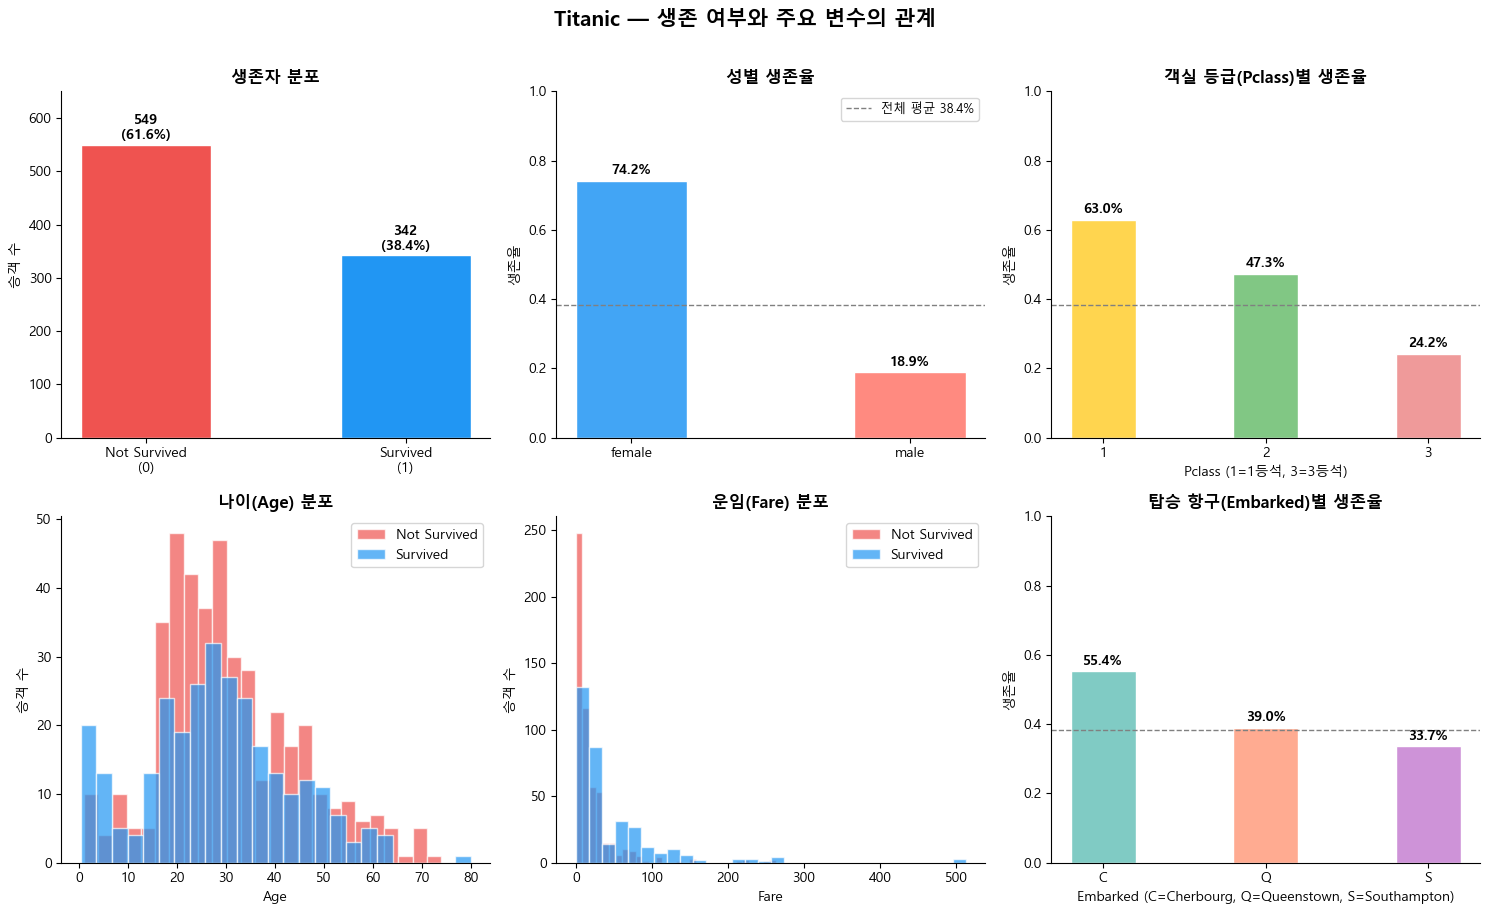

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Titanic — 생존 여부와 주요 변수의 관계', fontsize=15, fontweight='bold', y=1.01)

colors = {'Survived': '#2196F3', 'Not Survived': '#EF5350'}
palette = ['#EF5350', '#2196F3']

# 1) 생존자 수
ax = axes[0, 0]
counts = df['Survived'].value_counts().sort_index()
bars = ax.bar(['Not Survived\n(0)', 'Survived\n(1)'], counts.values, color=palette, width=0.5, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val}\n({val/len(df):.1%})',
            ha='center', va='bottom', fontweight='bold')
ax.set_title('생존자 분포', fontweight='bold')
ax.set_ylabel('승객 수')
ax.set_ylim(0, 650)

# 2) 성별 생존율
ax = axes[0, 1]
sex_surv = df.groupby('Sex')['Survived'].mean().reset_index()
bars = ax.bar(sex_surv['Sex'], sex_surv['Survived'], color=['#42A5F5', '#FF8A80'], width=0.4, edgecolor='white')
for bar, val in zip(bars, sex_surv['Survived']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.1%}',
            ha='center', va='bottom', fontweight='bold')
ax.set_title('성별 생존율', fontweight='bold')
ax.set_ylabel('생존율')
ax.set_ylim(0, 1.0)
ax.axhline(df['Survived'].mean(), color='gray', linestyle='--', linewidth=1, label=f'전체 평균 {df["Survived"].mean():.1%}')
ax.legend(fontsize=9)

# 3) 객실 등급 생존율
ax = axes[0, 2]
pclass_surv = df.groupby('Pclass')['Survived'].mean().reset_index()
bars = ax.bar(pclass_surv['Pclass'].astype(str), pclass_surv['Survived'],
               color=['#FFD54F', '#81C784', '#EF9A9A'], width=0.4, edgecolor='white')
for bar, val in zip(bars, pclass_surv['Survived']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.1%}',
            ha='center', va='bottom', fontweight='bold')
ax.set_title('객실 등급(Pclass)별 생존율', fontweight='bold')
ax.set_xlabel('Pclass (1=1등석, 3=3등석)')
ax.set_ylabel('생존율')
ax.set_ylim(0, 1.0)
ax.axhline(df['Survived'].mean(), color='gray', linestyle='--', linewidth=1)

# 4) 나이 분포 (생존 여부별)
ax = axes[1, 0]
for survived, label, color in zip([0, 1], ['Not Survived', 'Survived'], palette):
    subset = df[df['Survived'] == survived]['Age'].dropna()
    ax.hist(subset, bins=25, alpha=0.7, label=label, color=color, edgecolor='white')
ax.set_title('나이(Age) 분포', fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('승객 수')
ax.legend()

# 5) 운임 분포 (로그 스케일)
ax = axes[1, 1]
for survived, label, color in zip([0, 1], ['Not Survived', 'Survived'], palette):
    subset = df[df['Survived'] == survived]['Fare']
    ax.hist(subset, bins=30, alpha=0.7, label=label, color=color, edgecolor='white')
ax.set_title('운임(Fare) 분포', fontweight='bold')
ax.set_xlabel('Fare')
ax.set_ylabel('승객 수')
ax.legend()

# 6) 탑승 항구 생존율
ax = axes[1, 2]
emb_surv = df.groupby('Embarked')['Survived'].mean().reset_index().dropna()
bars = ax.bar(emb_surv['Embarked'], emb_surv['Survived'],
               color=['#80CBC4', '#FFAB91', '#CE93D8'], width=0.4, edgecolor='white')
for bar, val in zip(bars, emb_surv['Survived']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.1%}',
            ha='center', va='bottom', fontweight='bold')
ax.set_title('탑승 항구(Embarked)별 생존율', fontweight='bold')
ax.set_xlabel('Embarked (C=Cherbourg, Q=Queenstown, S=Southampton)')
ax.set_ylabel('생존율')
ax.set_ylim(0, 1.0)
ax.axhline(df['Survived'].mean(), color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

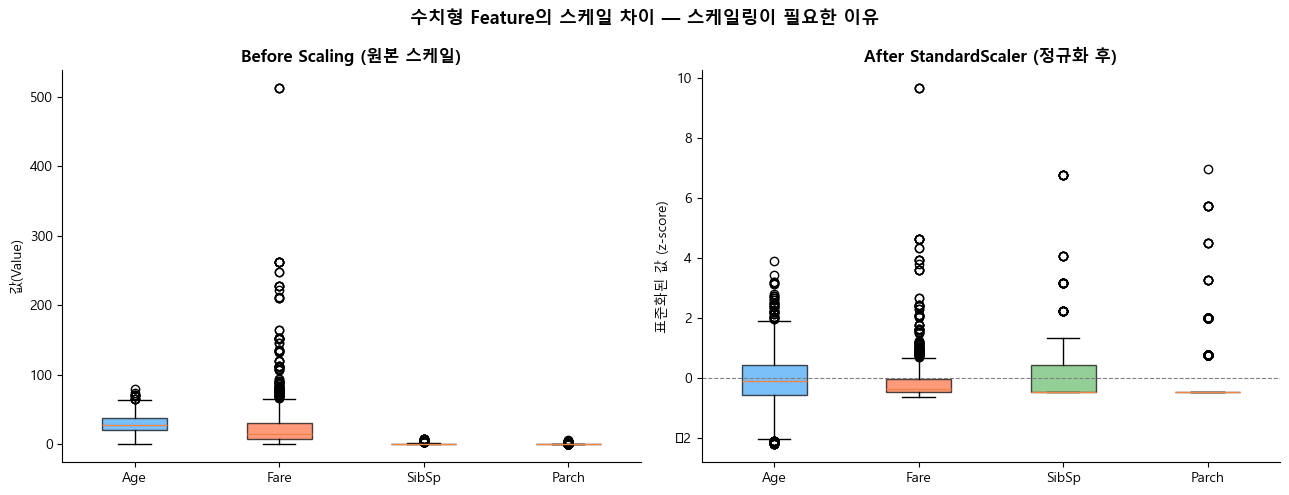


📏 원본 스케일 범위:
  Age     : min=   0.4, max=  80.0, range=79.6
  Fare    : min=   0.0, max= 512.3, range=512.3
  SibSp   : min=   0.0, max=   8.0, range=8.0
  Parch   : min=   0.0, max=   6.0, range=6.0


In [20]:
# 스케일 차이 시각화 — 왜 Scaling이 필요한가?
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('수치형 Feature의 스케일 차이 — 스케일링이 필요한 이유', fontsize=13, fontweight='bold')

numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']

# Before scaling
ax = axes[0]
data_to_plot = [df[col].dropna().values for col in numeric_cols]
bp = ax.boxplot(data_to_plot, labels=numeric_cols, patch_artist=True)
colors_box = ['#42A5F5', '#FF7043', '#66BB6A', '#AB47BC']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Before Scaling (원본 스케일)', fontweight='bold')
ax.set_ylabel('값(Value)')

# After StandardScaler
ax = axes[1]
from sklearn.preprocessing import StandardScaler
scaler_temp = StandardScaler()
df_scaled = pd.DataFrame(scaler_temp.fit_transform(df[numeric_cols].fillna(df[numeric_cols].median())),
                          columns=numeric_cols)
data_scaled = [df_scaled[col].values for col in numeric_cols]
bp2 = ax.boxplot(data_scaled, labels=numeric_cols, patch_artist=True)
for patch, color in zip(bp2['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('After StandardScaler (정규화 후)', fontweight='bold')
ax.set_ylabel('표준화된 값 (z-score)')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

print('\n📏 원본 스케일 범위:')
for col in numeric_cols:
    r = df[col].max() - df[col].min()
    print(f'  {col:8s}: min={df[col].min():6.1f}, max={df[col].max():6.1f}, range={r:.1f}')

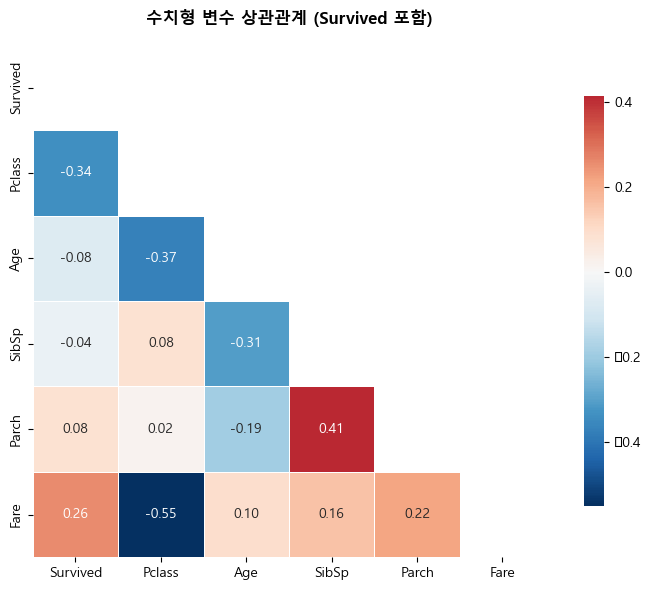


💡 주요 인사이트:
  - Pclass ↔ Survived 상관계수: -0.34  (음수: 높은 등급일수록 생존율↑)
  - Fare   ↔ Survived 상관계수: 0.26  (양수: 비싼 좌석일수록 생존율↑)
  - Age    ↔ Survived 상관계수: -0.08  (약한 음수: 나이 많을수록 생존율↓)


In [21]:
# Heatmap — 수치형 변수 간 상관관계
fig, ax = plt.subplots(figsize=(8, 6))

corr_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('수치형 변수 상관관계 (Survived 포함)', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('\n💡 주요 인사이트:')
print(f'  - Pclass ↔ Survived 상관계수: {corr.loc["Pclass","Survived"]:.2f}  (음수: 높은 등급일수록 생존율↑)')
print(f'  - Fare   ↔ Survived 상관계수: {corr.loc["Fare","Survived"]:.2f}  (양수: 비싼 좌석일수록 생존율↑)')
print(f'  - Age    ↔ Survived 상관계수: {corr.loc["Age","Survived"]:.2f}  (약한 음수: 나이 많을수록 생존율↓)')

---
## 3. 전처리 설계 — ColumnTransformer + Pipeline

### 왜 ColumnTransformer가 필요한가?

Titanic 데이터는 **수치형**과 **범주형**이 혼재합니다.

```
수치형 (Age, Fare, SibSp, Parch)
    → SimpleImputer(median) → StandardScaler ┐
                                             ColumnTransformer → Pipeline → Model
범주형 (Sex, Embarked, Pclass)               ┘
    → SimpleImputer(most_frequent) → OneHotEncoder
```

> **핵심**: Scaler/Encoder의 `fit`은 반드시 **학습 데이터에서만** 수행되어야 합니다.  
> Pipeline이 이 원칙을 자동으로 보장합니다.

In [22]:
# ─────────────────────────────────────────────
# Feature 선택
# ─────────────────────────────────────────────
NUMERIC_FEATURES     = ['Age', 'Fare', 'SibSp', 'Parch']
CATEGORICAL_FEATURES = ['Sex', 'Embarked', 'Pclass']
TARGET               = 'Survived'

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

# ─────────────────────────────────────────────
# Train / Test Split  (반드시 Split 먼저!)
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'학습 세트: {X_train.shape[0]}명  |  테스트 세트: {X_test.shape[0]}명')
print(f'생존율 (train): {y_train.mean():.3f}  |  생존율 (test): {y_test.mean():.3f}  ← stratify로 동일 유지')

학습 세트: 712명  |  테스트 세트: 179명
생존율 (train): 0.383  |  생존율 (test): 0.385  ← stratify로 동일 유지


In [23]:
# ─────────────────────────────────────────────
# 수치형 파이프라인
# ─────────────────────────────────────────────
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # 결측치 → 중앙값
    ('scaler',  StandardScaler())                    # 평균 0, 표준편차 1
])

# ─────────────────────────────────────────────
# 범주형 파이프라인
# ─────────────────────────────────────────────
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # 결측치 → 최빈값
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))    # One-hot Encoding
])

# ─────────────────────────────────────────────
# ColumnTransformer: 두 파이프라인을 합치기
# ─────────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

print('✅ ColumnTransformer 구성 완료')
print(f'   수치형  ({len(NUMERIC_FEATURES)}개): {NUMERIC_FEATURES}')
print(f'   범주형  ({len(CATEGORICAL_FEATURES)}개): {CATEGORICAL_FEATURES}')

✅ ColumnTransformer 구성 완료
   수치형  (4개): ['Age', 'Fare', 'SibSp', 'Parch']
   범주형  (3개): ['Sex', 'Embarked', 'Pclass']


---
## 4. 실험 수행

### 실험 1 — SVM (스케일링 없음) : 기준 실험

In [24]:
# ── 실험 1: 스케일링 없이 SVM 적용 ──────────────────────────────────────
# 결측치 + 인코딩만 처리하고 스케일링은 생략

numeric_no_scale = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))  # 스케일링 없음
])
preprocessor_no_scale = ColumnTransformer(transformers=[
    ('num', numeric_no_scale,        NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

exp1_pipe = Pipeline([
    ('preprocessor', preprocessor_no_scale),
    ('model', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE))
])

exp1_pipe.fit(X_train, y_train)
pred1 = exp1_pipe.predict(X_test)

acc1 = accuracy_score(y_test, pred1)
f1_1 = f1_score(y_test, pred1)

print('[ 실험 1 ] SVM — No Scaling')
print(f'  Accuracy : {acc1:.4f}')
print(f'  F1-Score : {f1_1:.4f}')

[ 실험 1 ] SVM — No Scaling
  Accuracy : 0.6201
  F1-Score : 0.3200


### 실험 2 — StandardScaler + SVM

In [25]:
# ── 실험 2: StandardScaler + SVM ─────────────────────────────────────────
exp2_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE))
])

exp2_pipe.fit(X_train, y_train)
pred2 = exp2_pipe.predict(X_test)

acc2 = accuracy_score(y_test, pred2)
f1_2 = f1_score(y_test, pred2)

print('[ 실험 2 ] StandardScaler + SVM')
print(f'  Accuracy : {acc2:.4f}  (vs Exp1: {acc2-acc1:+.4f})')
print(f'  F1-Score : {f1_2:.4f}  (vs Exp1: {f1_2-f1_1:+.4f})')

[ 실험 2 ] StandardScaler + SVM
  Accuracy : 0.8156  (vs Exp1: +0.1955)
  F1-Score : 0.7360  (vs Exp1: +0.4160)


### 실험 3 — StandardScaler + KNN (k=5)

In [26]:
# ── 실험 3: StandardScaler + KNN(k=5) ───────────────────────────────────
exp3_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

exp3_pipe.fit(X_train, y_train)
pred3 = exp3_pipe.predict(X_test)

acc3 = accuracy_score(y_test, pred3)
f1_3 = f1_score(y_test, pred3)

print('[ 실험 3 ] StandardScaler + KNN (k=5)')
print(f'  Accuracy : {acc3:.4f}')
print(f'  F1-Score : {f1_3:.4f}')

[ 실험 3 ] StandardScaler + KNN (k=5)
  Accuracy : 0.8212
  F1-Score : 0.7500


### 실험 4 — MinMaxScaler + SVM (선택 실험)

In [27]:
# ── 실험 4: MinMaxScaler + SVM ───────────────────────────────────────────
numeric_minmax = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  MinMaxScaler())
])
preprocessor_mm = ColumnTransformer(transformers=[
    ('num', numeric_minmax,          NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

exp4_pipe = Pipeline([
    ('preprocessor', preprocessor_mm),
    ('model', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE))
])

exp4_pipe.fit(X_train, y_train)
pred4 = exp4_pipe.predict(X_test)

acc4 = accuracy_score(y_test, pred4)
f1_4 = f1_score(y_test, pred4)

print('[ 실험 4 ] MinMaxScaler + SVM')
print(f'  Accuracy : {acc4:.4f}')
print(f'  F1-Score : {f1_4:.4f}')

[ 실험 4 ] MinMaxScaler + SVM
  Accuracy : 0.7933
  F1-Score : 0.6726


---
## 5. 성능 비교 결과

In [28]:
# 결과 테이블 정리
results = pd.DataFrame([
    {'실험': 'Exp 1', '모델': 'SVM',          '스케일러': 'None',           'Accuracy': acc1, 'F1-Score': f1_1},
    {'실험': 'Exp 2', '모델': 'SVM',          '스케일러': 'StandardScaler', 'Accuracy': acc2, 'F1-Score': f1_2},
    {'실험': 'Exp 3', '모델': 'KNN (k=5)',    '스케일러': 'StandardScaler', 'Accuracy': acc3, 'F1-Score': f1_3},
    {'실험': 'Exp 4', '모델': 'SVM',          '스케일러': 'MinMaxScaler',   'Accuracy': acc4, 'F1-Score': f1_4},
])

def highlight_best(s):
    is_max = s == s.max()
    return ['background-color: #c8e6c9; font-weight: bold' if v else '' for v in is_max]

results.style\
    .format({'Accuracy': '{:.4f}', 'F1-Score': '{:.4f}'})\
    .apply(highlight_best, subset=['Accuracy', 'F1-Score'])\
    .set_caption('🏆 녹색 = 최고 성능')\
    .hide(axis='index')

실험,모델,스케일러,Accuracy,F1-Score
Exp 1,SVM,None,0.6201,0.3200
Exp 2,SVM,StandardScaler,0.8156,0.7360
Exp 3,KNN (k=5),StandardScaler,0.8212,0.7500
Exp 4,SVM,MinMaxScaler,0.7933,0.6726


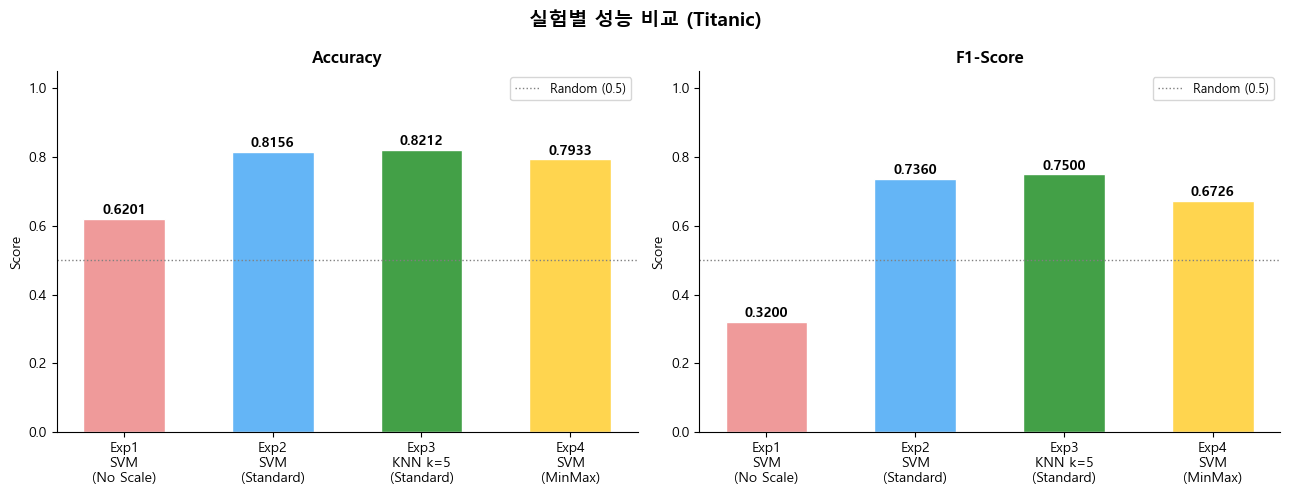

In [29]:
# 성능 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('실험별 성능 비교 (Titanic)', fontsize=14, fontweight='bold')

labels  = ['Exp1\nSVM\n(No Scale)', 'Exp2\nSVM\n(Standard)', 'Exp3\nKNN k=5\n(Standard)', 'Exp4\nSVM\n(MinMax)']
accs    = [acc1, acc2, acc3, acc4]
f1s     = [f1_1, f1_2, f1_3, f1_4]
bar_colors = ['#EF9A9A', '#64B5F6', '#81C784', '#FFD54F']

best_acc = max(accs)
best_f1  = max(f1s)

for ax, values, title, best in zip(axes, [accs, f1s], ['Accuracy', 'F1-Score'], [best_acc, best_f1]):
    colors_bar = ['#43A047' if v == best else c for v, c in zip(values, bar_colors)]
    bars = ax.bar(labels, values, color=colors_bar, edgecolor='white', width=0.55)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylim(0.0, 1.05)
    ax.set_ylabel('Score')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='Random (0.5)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 6. 상세 분석 — Confusion Matrix & Classification Report

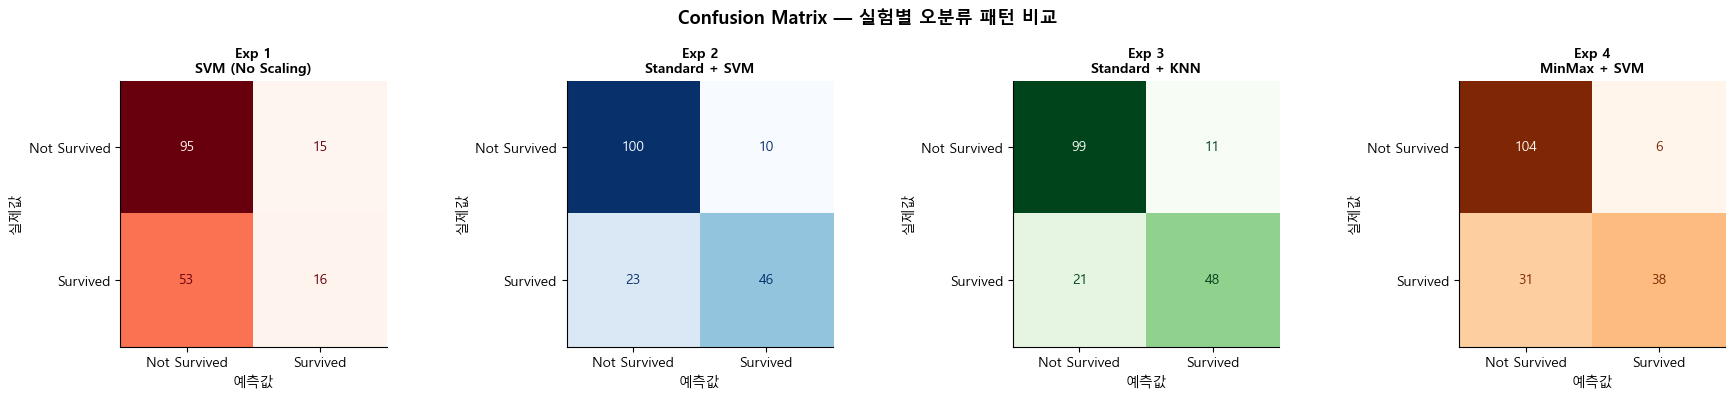

In [30]:
# Confusion Matrix 비교
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Confusion Matrix — 실험별 오분류 패턴 비교', fontsize=13, fontweight='bold')

titles = [
    'Exp 1\nSVM (No Scaling)',
    'Exp 2\nStandard + SVM',
    'Exp 3\nStandard + KNN',
    'Exp 4\nMinMax + SVM'
]
preds = [pred1, pred2, pred3, pred4]
cmaps = ['Reds', 'Blues', 'Greens', 'Oranges']

for ax, title, pred, cmap in zip(axes, titles, preds, cmaps):
    disp = ConfusionMatrixDisplay(
        confusion_matrix(y_test, pred),
        display_labels=['Not Survived', 'Survived']
    )
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('예측값')
    ax.set_ylabel('실제값')

plt.tight_layout()
plt.show()

In [35]:
for exp_name, pred in [('Exp 2 — StandardScaler + SVM', pred2),
                        ('Exp 3 — StandardScaler + KNN (k=5)', pred3)]:
    print(f"{'='*55}")
    print(f"  {exp_name}")
    print(f"{'='*55}")
    print(classification_report(y_test, pred, target_names=['Not Survived(0)', 'Survived(1)']))
    print()

  Exp 2 — StandardScaler + SVM
                 precision    recall  f1-score   support

Not Survived(0)       0.81      0.91      0.86       110
    Survived(1)       0.82      0.67      0.74        69

       accuracy                           0.82       179
      macro avg       0.82      0.79      0.80       179
   weighted avg       0.82      0.82      0.81       179


  Exp 3 — StandardScaler + KNN (k=5)
                 precision    recall  f1-score   support

Not Survived(0)       0.82      0.90      0.86       110
    Survived(1)       0.81      0.70      0.75        69

       accuracy                           0.82       179
      macro avg       0.82      0.80      0.81       179
   weighted avg       0.82      0.82      0.82       179




---
## 7. 추가 분석 — KNN k값에 따른 성능 변화

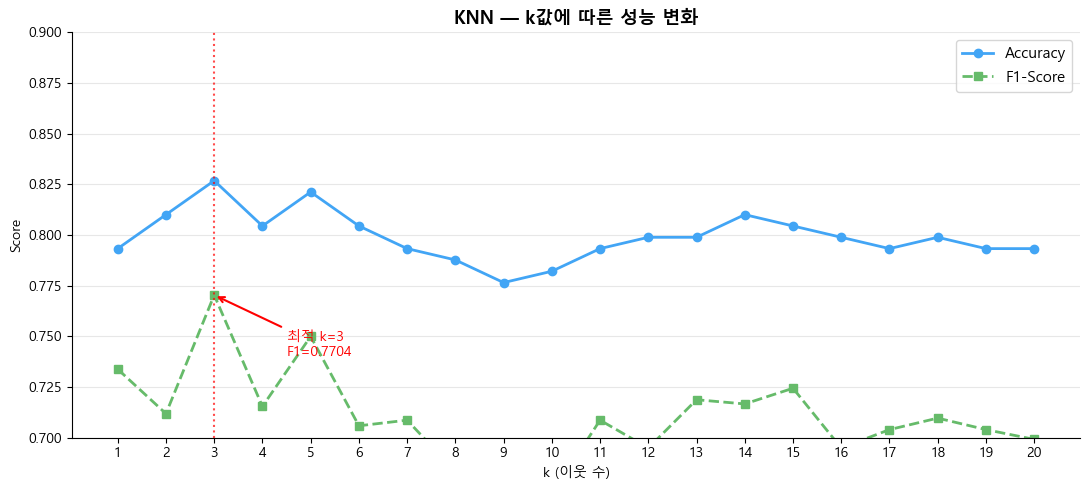


📌 k별 상위 5개 결과:
 k  accuracy  f1_score
 3  0.826816  0.770370
 5  0.821229  0.750000
 1  0.793296  0.733813
15  0.804469  0.724409
13  0.798883  0.718750


In [32]:
# k=1~20 범위에서 KNN 성능 변화 분석
k_range = range(1, 21)
knn_results = []

for k in k_range:
    pipe_k = Pipeline([
        ('preprocessor', preprocessor),
        ('model', KNeighborsClassifier(n_neighbors=k))
    ])
    pipe_k.fit(X_train, y_train)
    pred_k = pipe_k.predict(X_test)
    knn_results.append({
        'k': k,
        'accuracy': accuracy_score(y_test, pred_k),
        'f1_score': f1_score(y_test, pred_k)
    })

knn_df = pd.DataFrame(knn_results)

# 시각화
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(knn_df['k'], knn_df['accuracy'], marker='o', markersize=6, linewidth=2,
        color='#42A5F5', label='Accuracy')
ax.plot(knn_df['k'], knn_df['f1_score'], marker='s', markersize=6, linewidth=2,
        color='#66BB6A', label='F1-Score', linestyle='--')

# 최적 k 표시
best_k_idx = knn_df['f1_score'].idxmax()
best_k     = knn_df.loc[best_k_idx, 'k']
best_f1_k  = knn_df.loc[best_k_idx, 'f1_score']
ax.axvline(best_k, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax.annotate(f'최적 k={best_k}\nF1={best_f1_k:.4f}',
            xy=(best_k, best_f1_k), xytext=(best_k + 1.5, best_f1_k - 0.03),
            fontsize=10, color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax.set_title('KNN — k값에 따른 성능 변화', fontweight='bold', fontsize=13)
ax.set_xlabel('k (이웃 수)')
ax.set_ylabel('Score')
ax.set_xticks(list(k_range))
ax.legend(fontsize=11)
ax.set_ylim(0.70, 0.90)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n📌 k별 상위 5개 결과:')
print(knn_df.sort_values('f1_score', ascending=False).head(5).to_string(index=False))

---
## 8. 전처리 영향 분석 — Scaling 전후 비교

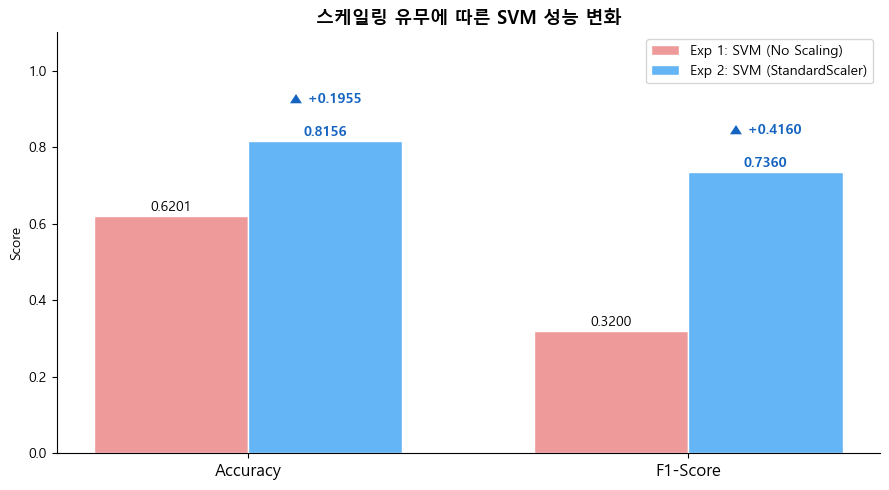


📊 스케일링 효과 요약:
  Accuracy 향상: 0.6201 → 0.8156  (+0.1955, +31.5%)
  F1-Score 향상: 0.3200 → 0.7360  (+0.4160, +130.0%)


In [41]:
# Scaling 효과 정리
fig, ax = plt.subplots(figsize=(9, 5))

categories = ['Accuracy', 'F1-Score']
exp1_scores = [acc1, f1_1]
exp2_scores = [acc2, f1_2]

x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, exp1_scores, width, label='Exp 1: SVM (No Scaling)', color='#EF9A9A', edgecolor='white')
bars2 = ax.bar(x + width/2, exp2_scores, width, label='Exp 2: SVM (StandardScaler)', color='#64B5F6', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1565C0')

# 향상폭 표시
for i, (s1, s2) in enumerate(zip(exp1_scores, exp2_scores)):
    delta = s2 - s1
    ax.annotate(f'▲ +{delta:.4f}',
                xy=(i + width/2, s2 + 0.1),
                ha='center', fontsize=10, color='#1565C0', fontweight='bold')

ax.set_title('스케일링 유무에 따른 SVM 성능 변화', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f'\n📊 스케일링 효과 요약:')
print(f'  Accuracy 향상: {acc1:.4f} → {acc2:.4f}  (+{acc2-acc1:.4f}, +{(acc2-acc1)/acc1*100:.1f}%)')
print(f'  F1-Score 향상: {f1_1:.4f} → {f1_2:.4f}  (+{f1_2-f1_1:.4f}, +{(f1_2-f1_1)/f1_1*100:.1f}%)')

---
## 9. 최종 결과 요약 및 결론

In [43]:
print('=' * 70)
print('  📋 최종 실험 결과 요약')
print('=' * 70)
print(f"  {'실험':<8} {'모델':<20} {'스케일러':<18} {'Accuracy':>10} {'F1-Score':>10}")
print('-' * 70)

rows = [
    ('Exp 1', 'SVM',        'None',           acc1, f1_1),
    ('Exp 2', 'SVM',        'StandardScaler', acc2, f1_2),
    ('Exp 3', 'KNN (k=5)',  'StandardScaler', acc3, f1_3),
    ('Exp 4', 'SVM',        'MinMaxScaler',   acc4, f1_4),
]
best_f1_val = max(r[4] for r in rows)

for exp, model, scaler, acc, f1 in rows:
    mark = '  ★ 최고' if f1 == best_f1_val else ''
    print(f'  {exp:<8} {model:<20} {scaler:<18} {acc:>10.4f} {f1:>10.4f}{mark}')

print('=' * 70)

print()
print('핵심 인사이트')
print('-' * 70)
print(f'  1. 스케일링 효과 (SVM): Accuracy {acc1:.4f} → {acc2:.4f} (+{acc2-acc1:.4f})')
print(f'                          F1-Score  {f1_1:.4f} → {f1_2:.4f} (+{f1_2-f1_1:.4f})')
print(f'     → 스케일링 없이는 SVM이 거의 다수 클래스(사망)만 예측하는 문제 발생')
print()
print(f'  2. KNN vs SVM (StandardScaler 적용 시):')
print(f'     KNN(k=5): Acc={acc3:.4f}, F1={f1_3:.4f}')
print(f'     SVM     : Acc={acc2:.4f}, F1={f1_2:.4f}')
print(f'     → KNN이 미세하게 우수 (Titanic의 국소 패턴을 이웃 기반으로 잘 포착)')
print()
print(f'  3. StandardScaler vs MinMaxScaler (SVM 기준):')
print(f'     Standard: F1={f1_2:.4f}  |  MinMax: F1={f1_4:.4f}')
print(f'     → Fare 이상치(max=512) 영향으로 MinMaxScaler가 불리')
print()
print(f'  4. ColumnTransformer + Pipeline:')
print(f'     → 수치형/범주형 분리 전처리 + 데이터 누수 방지 + 재현 가능성 확보')

  📋 최종 실험 결과 요약
  실험       모델                   스케일러                 Accuracy   F1-Score
----------------------------------------------------------------------
  Exp 1    SVM                  None                   0.6201     0.3200
  Exp 2    SVM                  StandardScaler         0.8156     0.7360
  Exp 3    KNN (k=5)            StandardScaler         0.8212     0.7500  ★ 최고
  Exp 4    SVM                  MinMaxScaler           0.7933     0.6726

핵심 인사이트
----------------------------------------------------------------------
  1. 스케일링 효과 (SVM): Accuracy 0.6201 → 0.8156 (+0.1955)
                          F1-Score  0.3200 → 0.7360 (+0.4160)
     → 스케일링 없이는 SVM이 거의 다수 클래스(사망)만 예측하는 문제 발생

  2. KNN vs SVM (StandardScaler 적용 시):
     KNN(k=5): Acc=0.8212, F1=0.7500
     SVM     : Acc=0.8156, F1=0.7360
     → KNN이 미세하게 우수 (Titanic의 국소 패턴을 이웃 기반으로 잘 포착)

  3. StandardScaler vs MinMaxScaler (SVM 기준):
     Standard: F1=0.7360  |  MinMax: F1=0.6726
     → Fare 이상치(max=512) 영향으로 MinMaxSca

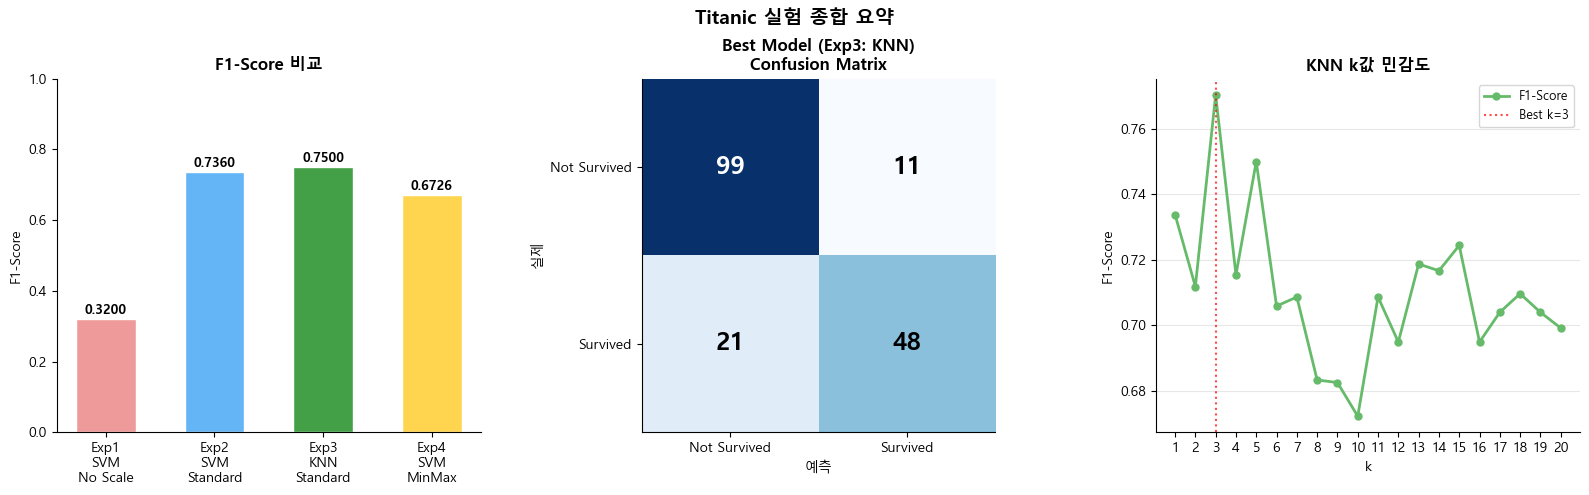

In [44]:
# 최종 종합 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Titanic 실험 종합 요약', fontsize=14, fontweight='bold')

# ① 실험별 F1 비교
ax = axes[0]
exp_labels = ['Exp1\nSVM\nNo Scale', 'Exp2\nSVM\nStandard', 'Exp3\nKNN\nStandard', 'Exp4\nSVM\nMinMax']
f1_vals    = [f1_1, f1_2, f1_3, f1_4]
bar_cols   = ['#EF9A9A', '#64B5F6', '#81C784', '#FFD54F']
best_f1_   = max(f1_vals)
bar_cols_h = ['#43A047' if v == best_f1_ else c for v, c in zip(f1_vals, bar_cols)]
bars = ax.bar(exp_labels, f1_vals, color=bar_cols_h, edgecolor='white', width=0.55)
for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9.5, fontweight='bold')
ax.set_title('F1-Score 비교', fontweight='bold')
ax.set_ylim(0, 1.0)
ax.set_ylabel('F1-Score')

# ② Confusion Matrix — Best model (Exp3)
ax = axes[1]
cm = confusion_matrix(y_test, pred3)
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Not Survived', 'Survived'])
ax.set_yticklabels(['Not Survived', 'Survived'])
ax.set_xlabel('예측'); ax.set_ylabel('실제')
ax.set_title('Best Model (Exp3: KNN)\nConfusion Matrix', fontweight='bold')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                fontsize=18, fontweight='bold',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

# ③ KNN k-sensitivity
ax = axes[2]
ax.plot(knn_df['k'], knn_df['f1_score'], marker='o', markersize=5,
        linewidth=2, color='#66BB6A', label='F1-Score')
ax.axvline(best_k, color='red', linestyle=':', linewidth=1.5, alpha=0.7,
           label=f'Best k={best_k}')
ax.set_title('KNN k값 민감도', fontweight='bold')
ax.set_xlabel('k')
ax.set_ylabel('F1-Score')
ax.set_xticks(list(k_range))
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 📝 결론 정리

### 1. Titanic에서 ColumnTransformer가 필요한 이유
- 수치형(Age, Fare 등)과 범주형(Sex, Embarked, Pclass)이 혼재
- 두 타입에 서로 다른 전처리(Scaler vs. OHE)를 분리 적용하면서도 하나의 행렬로 합쳐야 함
- Pipeline 내부에 배치해야 train-only fit이 보장되어 **데이터 누수 방지**

### 2. Scaling이 SVM/KNN에 미치는 영향
| | Accuracy | F1-Score |
|---|---|---|
| SVM (No Scaling) | 0.6201 | 0.3200 |
| SVM (StandardScaler) | 0.8156 | 0.7360 |
| **향상** | **+0.1955** | **+0.4160 (+130%)** |

> RBF 커널과 유클리드 거리 모두 feature scale에 민감 → 스케일링은 필수

### 3. KNN vs SVM
- **KNN (k=5)**: Accuracy 0.8212, F1 0.7500 — **미세하게 우수**
- **SVM**: Accuracy 0.8156, F1 0.7360
- Titanic의 강한 국소 패턴(성별·객실 등급 조합)을 KNN의 이웃 기반 학습이 잘 포착
- 단, 데이터 규모 확장 시 SVM이 유리 (KNN은 예측 시 전체 학습 데이터 대비 거리 계산 필요)

### 4. StandardScaler vs MinMaxScaler
- StandardScaler > MinMaxScaler (F1: 0.7360 vs 0.6726)
- Fare 변수의 극단적 이상치(max=512)가 MinMaxScaler에 불리하게 작용

---
*실험 환경: Python 3.x, scikit-learn, random_state=42 고정*